<a href="https://colab.research.google.com/github/KIJOTARO/googlecolab/blob/main/TopicModel2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INSTALASI LIBRARY


In [1]:
!pip install -q -U pip
!pip install -q bertopic==0.16.4 sentence-transformers umap-learn hdbscan
!pip install -q sastrawi nltk emoji wordcloud
!pip install -q pandas numpy matplotlib seaborn plotly scikit-learn langdetect gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# IMPORT LIBRARY

In [2]:
import re
import io
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files, drive
from IPython.display import display

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

from wordcloud import WordCloud
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


# LOAD DATASET

In [3]:
print("📂 Silakan upload file dataset CSV ...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]), engine='python', on_bad_lines='skip')
print(f"✅ Data awal dimuat: {len(df)} baris")

if 'full_text' not in df.columns:
    raise ValueError("❌ Kolom 'full_text' tidak ditemukan dalam dataset")

# Ekstraksi waktu untuk grafik trend
date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower() or 'waktu' in c.lower() or 'created' in c.lower()]
if len(date_cols) > 0:
    date_col = date_cols[0]
    df['waktu_tweet'] = pd.to_datetime(df[date_col], errors='coerce').dt.tz_localize(None)
    print(f"✅ Kolom waktu ditemukan: '{date_col}'")
else:
    df['waktu_tweet'] = pd.date_range(start='2025-01-01', end='2025-09-30', periods=len(df))
    print("⚠️ Kolom waktu tidak ditemukan. Membuat tanggal simulasi Jan-Sep 2025.")

📂 Silakan upload file dataset CSV ...


Saving data-MBG.csv to data-MBG.csv
✅ Data awal dimuat: 1116 baris
✅ Kolom waktu ditemukan: 'created_at'


# CASE FOLDING

In [4]:
df['step_1_case_folding'] = df['full_text'].astype(str).str.lower()

print("🔍 HASIL STEP 1 (Semua huruf menjadi kecil):")
display(df[['full_text', 'step_1_case_folding']].head(10))

🔍 HASIL STEP 1 (Semua huruf menjadi kecil):


,full_text,step_1_case_folding
0,ujicoba MBG ini telah dilakukan sebelum pelant...,ujicoba mbg ini telah dilakukan sebelum pelant...
1,BGN bergerak cepat! Tim khusus dibentuk untuk ...,bgn bergerak cepat! tim khusus dibentuk untuk ...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen pemerintah diwujudkan melalui penyemp...
3,Badan Gizi Nasional (BGN) menonaktifkan sement...,badan gizi nasional (bgn) menonaktifkan sement...
4,MBG menjadi salah satu program pemerintah yg s...,mbg menjadi salah satu program pemerintah yg s...
5,@sarkasinaja @txtdrimedia Menurutku ini tuh ma...,@sarkasinaja @txtdrimedia menurutku ini tuh ma...
6,Kasus dugaan keracunan dalam program Makan Ber...,kasus dugaan keracunan dalam program makan ber...
7,Proyek Makan Bergizi Gratis Dikuasai Segelinti...,proyek makan bergizi gratis dikuasai segelinti...
8,@velodrone_id @NyaiNeneng @okeh_fik Gibran mel...,@velodrone_id @nyaineneng @okeh_fik gibran mel...
9,Bill Gates Gelontorkan Dana 7-8 Triliun Rupiah...,bill gates gelontorkan dana 7-8 triliun rupiah...


# CLEANING

In [5]:
def cleaning_process(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # Hapus URL
    text = re.sub(r'#\w+|@\w+', '', text)               # Hapus Hashtag & Mention
    text = re.sub(r'&amp;|&amp', ' ', text)              # Hapus sisa HTML seperti &amp;
    text = re.sub(r'\d+', '', text)                    # Hapus Angka
    text = re.sub(r'[^\w\s]', ' ', text)               # Hapus Simbol/Tanda Baca
    text = re.sub(r'\s+', ' ', text).strip()           # Hapus spasi berlebih
    return text

df['step_2_cleaning'] = df['step_1_case_folding'].apply(cleaning_process)

print("🔍 HASIL STEP 2 (Bersih dari URL, Angka, & Tanda Baca):")
display(df[['step_1_case_folding', 'step_2_cleaning']].head(10))

🔍 HASIL STEP 2 (Bersih dari URL, Angka, & Tanda Baca):


,step_1_case_folding,step_2_cleaning
0,ujicoba mbg ini telah dilakukan sebelum pelant...,ujicoba mbg ini telah dilakukan sebelum pelant...
1,bgn bergerak cepat! tim khusus dibentuk untuk ...,bgn bergerak cepat tim khusus dibentuk untuk s...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen pemerintah diwujudkan melalui penyemp...
3,badan gizi nasional (bgn) menonaktifkan sement...,badan gizi nasional bgn menonaktifkan sementar...
4,mbg menjadi salah satu program pemerintah yg s...,mbg menjadi salah satu program pemerintah yg s...
5,@sarkasinaja @txtdrimedia menurutku ini tuh ma...,menurutku ini tuh masalah dapur yg harus bikin...
6,kasus dugaan keracunan dalam program makan ber...,kasus dugaan keracunan dalam program makan ber...
7,proyek makan bergizi gratis dikuasai segelinti...,proyek makan bergizi gratis dikuasai segelinti...
8,@velodrone_id @nyaineneng @okeh_fik gibran mel...,gibran melakukan sidak ke sekolah dalam rangka...
9,bill gates gelontorkan dana 7-8 triliun rupiah...,bill gates gelontorkan dana triliun rupiah unt...


# TOKENISASI

In [6]:
df['step_3_token'] = df['step_2_cleaning'].apply(lambda x: x.split())

print("🔍 HASIL STEP 3 (Teks dipecah menjadi list kata):")
display(df[['step_2_cleaning', 'step_3_token']].head(10))

🔍 HASIL STEP 3 (Teks dipecah menjadi list kata):


,step_2_cleaning,step_3_token
0,ujicoba mbg ini telah dilakukan sebelum pelant...,"[ujicoba, mbg, ini, telah, dilakukan, sebelum,..."
1,bgn bergerak cepat tim khusus dibentuk untuk s...,"[bgn, bergerak, cepat, tim, khusus, dibentuk, ..."
2,komitmen pemerintah diwujudkan melalui penyemp...,"[komitmen, pemerintah, diwujudkan, melalui, pe..."
3,badan gizi nasional bgn menonaktifkan sementar...,"[badan, gizi, nasional, bgn, menonaktifkan, se..."
4,mbg menjadi salah satu program pemerintah yg s...,"[mbg, menjadi, salah, satu, program, pemerinta..."
5,menurutku ini tuh masalah dapur yg harus bikin...,"[menurutku, ini, tuh, masalah, dapur, yg, haru..."
6,kasus dugaan keracunan dalam program makan ber...,"[kasus, dugaan, keracunan, dalam, program, mak..."
7,proyek makan bergizi gratis dikuasai segelinti...,"[proyek, makan, bergizi, gratis, dikuasai, seg..."
8,gibran melakukan sidak ke sekolah dalam rangka...,"[gibran, melakukan, sidak, ke, sekolah, dalam,..."
9,bill gates gelontorkan dana triliun rupiah unt...,"[bill, gates, gelontorkan, dana, triliun, rupi..."


# NORMALISASI

In [7]:
#1. Load Dataset Kamus Alay (Standar Akademik - nasalsabila)
print("⏳ Sedang mengunduh Kamus Colloquial Indonesian Lexicon...")
url_kamus_alay = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"

try:
    df_kamus = pd.read_csv(url_kamus_alay)
    slang_dict_umum = dict(zip(df_kamus['slang'], df_kamus['formal']))
    print(f"✅ Kamus umum berhasil dimuat: {len(slang_dict_umum)} kata.")
except Exception as e:
    print(f"⚠️ Gagal mengunduh kamus online. Menggunakan kamus manual saja. Error: {e}")
    slang_dict_umum = {}

slang_dict_manual = {
    "mbg": "makan bergizi gratis", "bgn": "badan gizi nasional",
    "sppg": "satuan pelayanan pemenuhan gizi", "slhs": "standar laik higienis sanitasi",
    "preswapres": "presiden wakil presiden",
    "wapres": "wakil presiden", "pilpres": "pemilihan presiden",
    "paslon": "pasangan calon", "tps": "tempat pemungutan suara",
    "yg": "yang", "dg": "dengan", "sdh": "sudah", "udh": "sudah", "aja": "saja", "jd": "jadi", "utk": "untuk",
    "kalo": "kalau", "gak": "tidak", "tp": "tetapi", "slhs": "standar laik higienis sanitasi", "dgn": "dengan", "tdk": "tidak", "krn": "karena"
}
final_slang_dict = {**slang_dict_umum, **slang_dict_manual}

print(f"✅ Total kosakata kamus gabungan: {len(final_slang_dict)} kata.")

def normalize_hybrid(tokens):
    return [final_slang_dict[word] if word in final_slang_dict else word for word in tokens]

df['step_4_norm'] = df['step_3_token'].apply(normalize_hybrid)
df['step_4_str'] = df['step_4_norm'].apply(lambda x: " ".join(x))

print("🔍 HASIL STEP 4 (Kata gaul/singkatan diubah ke bentuk baku):")
display(df[['step_3_token', 'step_4_str']].head(10))

⏳ Sedang mengunduh Kamus Colloquial Indonesian Lexicon...
✅ Kamus umum berhasil dimuat: 4331 kata.
✅ Total kosakata kamus gabungan: 4340 kata.
🔍 HASIL STEP 4 (Kata gaul/singkatan diubah ke bentuk baku):


,step_3_token,step_4_str
0,"[ujicoba, mbg, ini, telah, dilakukan, sebelum,...",ujicoba makan bergizi gratis ini telah dilakuk...
1,"[bgn, bergerak, cepat, tim, khusus, dibentuk, ...",badan gizi nasional bergerak cepat tim khusus ...
2,"[komitmen, pemerintah, diwujudkan, melalui, pe...",komitmen pemerintah diwujudkan melalui penyemp...
3,"[badan, gizi, nasional, bgn, menonaktifkan, se...",badan gizi nasional badan gizi nasional menona...
4,"[mbg, menjadi, salah, satu, program, pemerinta...",makan bergizi gratis menjadi salah satu progra...
5,"[menurutku, ini, tuh, masalah, dapur, yg, haru...",menurutku ini tuh masalah dapur yang harus bik...
6,"[kasus, dugaan, keracunan, dalam, program, mak...",kasus dugaan keracunan dalam program makan ber...
7,"[proyek, makan, bergizi, gratis, dikuasai, seg...",proyek makan bergizi gratis dikuasai segelinti...
8,"[gibran, melakukan, sidak, ke, sekolah, dalam,...",gibran melakukan sidak ke sekolah dalam rangka...
9,"[bill, gates, gelontorkan, dana, triliun, rupi...",bill gates gelontorkan dana triliun rupiah unt...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


# STEMMING

In [8]:
print("⏳ Sedang memproses Stemming... Mohon tunggu.")
stemmer = StemmerFactory().create_stemmer()
df['step_5_stemmed'] = df['step_4_str'].apply(lambda x: stemmer.stem(x))

print("🔍 HASIL STEP 5 (Kata kembali ke bentuk dasar):")
display(df[['step_4_str', 'step_5_stemmed']].head(10))

⏳ Sedang memproses Stemming... Mohon tunggu.
🔍 HASIL STEP 5 (Kata kembali ke bentuk dasar):


,step_4_str,step_5_stemmed
0,ujicoba makan bergizi gratis ini telah dilakuk...,ujicoba makan gizi gratis ini telah laku belum...
1,badan gizi nasional bergerak cepat tim khusus ...,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen pemerintah diwujudkan melalui penyemp...,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional menona...,badan gizi nasional badan gizi nasional nonakt...
4,makan bergizi gratis menjadi salah satu progra...,makan gizi gratis jadi salah satu program peri...
5,menurutku ini tuh masalah dapur yang harus bik...,turut ini tuh masalah dapur yang harus bikin m...
6,kasus dugaan keracunan dalam program makan ber...,kasus duga racun dalam program makan gizi grat...
7,proyek makan bergizi gratis dikuasai segelinti...,proyek makan gizi gratis asai gelintir orang g...
8,gibran melakukan sidak ke sekolah dalam rangka...,gibran laku sidak ke sekolah dalam rangka tinj...
9,bill gates gelontorkan dana triliun rupiah unt...,bill gates gelontor dana triliun rupiah untuk ...


# STOPWORDS REMOVAL

In [9]:
factory = StopWordRemoverFactory()
stopwords_indonesia = set(factory.get_stop_words())

# Stopwords diperbanyak untuk membunuh noise Twitter yang merusak koherensi
custom_stopwords = {
    "amp", "rt", "t", "co", "http", "https", "gue", "lu", "elo", "gw", "lo", "aku", "saya",
    "kamu", "kita", "kami", "mereka", "dia", "nya", "orang", "tuh", "tu", "ga", "gak",
    "nggak", "enggak", "sih", "si", "nih", "ni", "mah", "dong", "kok", "yah", "deh", "dah",
    "aja", "saja", "ya", "yaa", "udah", "sdh", "udh", "blm", "belum", "lagi", "terus",
    "trus", "baru", "kalo", "klo", "kalau", "kl", "tp", "tapi", "yg", "yang", "dan", "di",
    "itu", "ini", "ke", "dari", "dr", "utk", "untuk", "dg", "dgn", "dengan", "sama", "buat",
    "biar", "supaya", "karena", "krn", "karna", "jadi", "kayak", "kyk", "seperti", "ala",
    "dalam", "bagi", "sampai", "mana", "soal", "bgt", "banget", "bisa", "mau", "akan",
    "ada", "juga", "kan", "dua", "banyak", "bikin", "semua", "masuk", "lihat",
    "liat", "tiap", "hal", "punya", "memang", "cara", "tak", "lebih", "pake", "pakai",
    "kasih", "pas", "dapat", "dapet", "tau", "tahu", "bilang", "ngomong", "benar", "betul",
    "salah", "baik", "cuma", "hanya", "bukan", "hari", "waktu", "saat", "masih",
    "mungkin", "kali", "sering", "terlalu", "paling", "sangat", "cukup", "kurang", "lain"
}

final_stopwords = stopwords_indonesia.union(custom_stopwords)

def remove_stop(text):
    words = text.split()
    clean_words = [w for w in words if w not in final_stopwords and len(w) > 2 and not w.isnumeric()]
    return " ".join(clean_words)

df['step_6_final'] = df['step_5_stemmed'].apply(remove_stop)

print("🔍 HASIL STEP 6 (Stopword Removal Selesai):")
display(df[['step_5_stemmed', 'step_6_final']].head(10))


🔍 HASIL STEP 6 (Stopword Removal Selesai):


,step_5_stemmed,step_6_final
0,ujicoba makan gizi gratis ini telah laku belum...,ujicoba makan gizi gratis laku lantik presiden...
1,badan gizi nasional gerak cepat tim khusus ben...,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen perintah wujud lalu sempurna lanjut p...,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional nonakt...,badan gizi nasional badan gizi nasional nonakt...
4,makan gizi gratis jadi salah satu program peri...,makan gizi gratis satu program perintah sedang...
5,turut ini tuh masalah dapur yang harus bikin m...,turut masalah dapur makan gizi gratis beberapa...
6,kasus duga racun dalam program makan gizi grat...,kasus duga racun program makan gizi gratis mak...
7,proyek makan gizi gratis asai gelintir orang g...,proyek makan gizi gratis asai gelintir gelinti...
8,gibran laku sidak ke sekolah dalam rangka tinj...,gibran laku sidak sekolah rangka tinjau progra...
9,bill gates gelontor dana triliun rupiah untuk ...,bill gates gelontor dana triliun rupiah progra...


# DATASET FINAL

In [10]:
df_final = df[df['step_6_final'].astype(str).str.len() > 5].copy()
df_final = df_final.reset_index(drop=True)

documents = df_final['step_6_final'].tolist()
timestamps = df_final['waktu_tweet'].tolist()

print("==========================================")
print(f"✅ Dokumen siap analisis: {len(documents)}")
print("==========================================")
# Jika len(documents) adalah 0, artinya filter terlalu ketat atau proses sebelumnya kosong.
if len(documents) == 0:
    print("❌ ERROR: Dokumen kosong. Periksa kembali proses Stopword/Stemming.")
else:
    display(df_final[['step_6_final']].head(5))

✅ Dokumen siap analisis: 1116


,step_6_final
0,ujicoba makan gizi gratis laku lantik presiden...
1,badan gizi nasional gerak cepat tim khusus ben...
2,komitmen perintah wujud lalu sempurna lanjut p...
3,badan gizi nasional badan gizi nasional nonakt...
4,makan gizi gratis satu program perintah sedang...


# WORDCLOUD

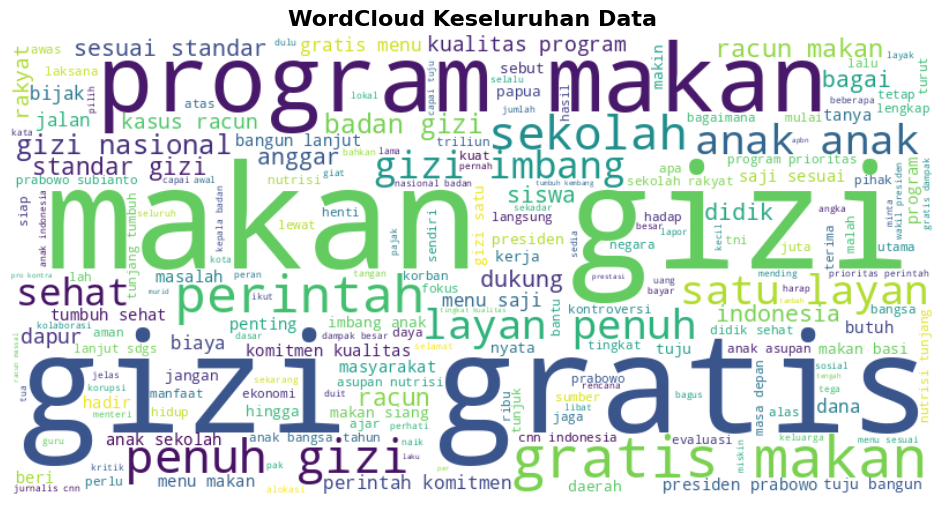

In [11]:
all_text = " ".join(documents)
if len(all_text.strip()) > 0:
    wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud Keseluruhan Data", fontsize=16, fontweight='bold')
    plt.show()
else:
    print("⚠️ Teks kosong, WordCloud tidak dapat ditampilkan.")

# PEMODELAN TOPIK - BERTopic

In [12]:
print("⏳ Sedang memuat model Embedding Multilingual...")
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
vectorizer_model = CountVectorizer(ngram_range=(1, 2), min_df=2)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
    )
hdbscan_model = HDBSCAN(
    min_cluster_size=5,       # Ubah ke 5-10 tergantung jumlah data
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

print("🚀 Melatih Model BERTopic...")
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    vectorizer_model=vectorizer_model,
    hdbscan_model=hdbscan_model,
    representation_model=KeyBERTInspired(),
    nr_topics=7,
    verbose=True
)

topics, probs = topic_model.fit_transform(documents)
df_final['topic'] = topics

# Tampilkan Info Topik
print("\n✅ Pemodelan Selesai. Berikut Daftar Topik:")

⏳ Sedang memuat model Embedding Multilingual...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

2026-03-10 13:48:12,267 - BERTopic - Embedding - Transforming documents to embeddings.


🚀 Melatih Model BERTopic...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

2026-03-10 13:48:51,280 - BERTopic - Embedding - Completed ✓
2026-03-10 13:48:51,282 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-10 13:49:04,137 - BERTopic - Dimensionality - Completed ✓
2026-03-10 13:49:04,139 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-10 13:49:04,196 - BERTopic - Cluster - Completed ✓
2026-03-10 13:49:04,197 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-03-10 13:49:35,580 - BERTopic - Representation - Completed ✓
2026-03-10 13:49:35,581 - BERTopic - Topic reduction - Reducing number of topics
2026-03-10 13:49:41,391 - BERTopic - Topic reduction - Reduced number of topics from 90 to 7



✅ Pemodelan Selesai. Berikut Daftar Topik:


# HASIL TOPIK

In [13]:
topic_info = topic_model.get_topic_info()
display(topic_info)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,216,-1_gratis makan_makan gratis_program makan_mak...,"[gratis makan, makan gratis, program makan, ma...",[program makan gizi gratis makan gizi gratis i...
1,0,640,0_program makan_gratis makan_makan gratis_menu...,"[program makan, gratis makan, makan gratis, me...",[perintah komitmen kualitas program makan gizi...
2,1,171,1_layan penuh_satu layan_layan_makan gizi,"[layan penuh, satu layan, layan, makan gizi, p...",[perintah tutup satu layan penuh gizi satu lay...
3,2,43,2_daya saing_ekonomi rakyat_ekonomi_bangun lanjut,"[daya saing, ekonomi rakyat, ekonomi, bangun l...",[pertamina lalu program bina laku umkm eksport...
4,3,32,3_sekolah rakyat_sekolah daya_lingkung sekolah...,"[sekolah rakyat, sekolah daya, lingkung sekola...",[menteri koordinator bidang daya masyarakat ab...
5,4,7,4_racun program_publik_informasi_transparansi ...,"[racun program, publik, informasi, transparans...",[badan gizi nasional gerak cepat tim khusus be...
6,5,7,5_vitamin mineral_vitamin_kandung nutrisi_nutrisi,"[vitamin mineral, vitamin, kandung nutrisi, nu...",[tambah asupan gizi anak singkong rebus satu m...


# VISUALISASI

In [14]:
# Barchart
fig_bar = topic_model.visualize_barchart()
fig_bar.show()

# Distance Map
fig_dist = topic_model.visualize_topics()
fig_dist.show()

# WORDCLOUD PER TOPIK

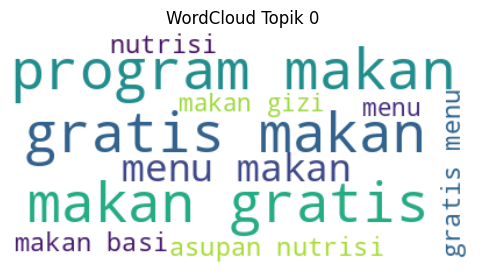

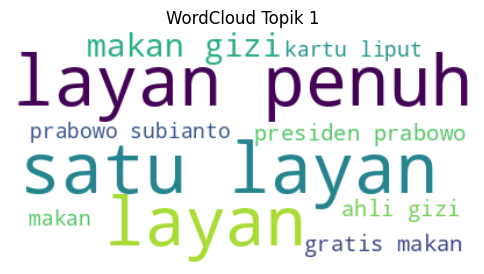

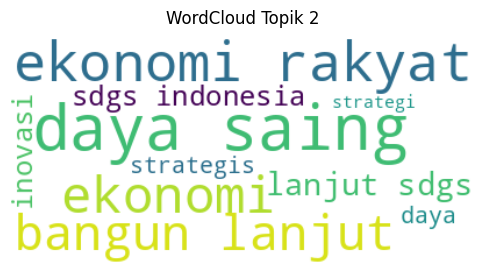

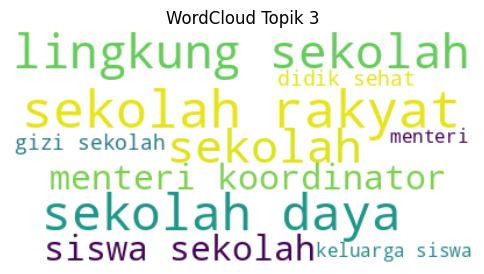

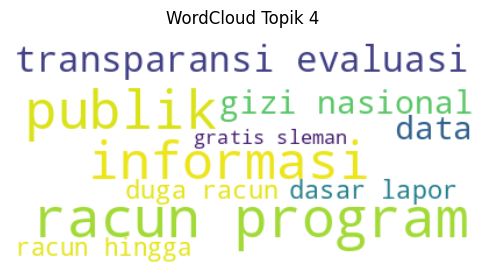

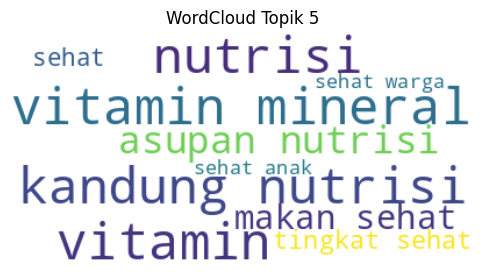

In [15]:
for t in topic_info.Topic:
    if t == -1: continue # Lewati outlier
    words = dict(topic_model.get_topic(t))
    wc = WordCloud(background_color="white").generate_from_frequencies(words)
    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"WordCloud Topik {t}")
    plt.show()

#EVALUASI TREND WAKTU

In [16]:
print("⏳ Menganalisis Pola Pembahasan (Trend Waktu)...")
topics_over_time = topic_model.topics_over_time(documents, timestamps, nr_bins=9)
topics_over_time.to_csv("trend_waktu_topik.csv", index=False)

fig_trend = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=6)
fig_trend.show()

⏳ Menganalisis Pola Pembahasan (Trend Waktu)...


9it [00:21,  2.40s/it]


# EVALUASI KOHERENSI

📊 Skor Koherensi Rata-rata (c_v): 0.4446


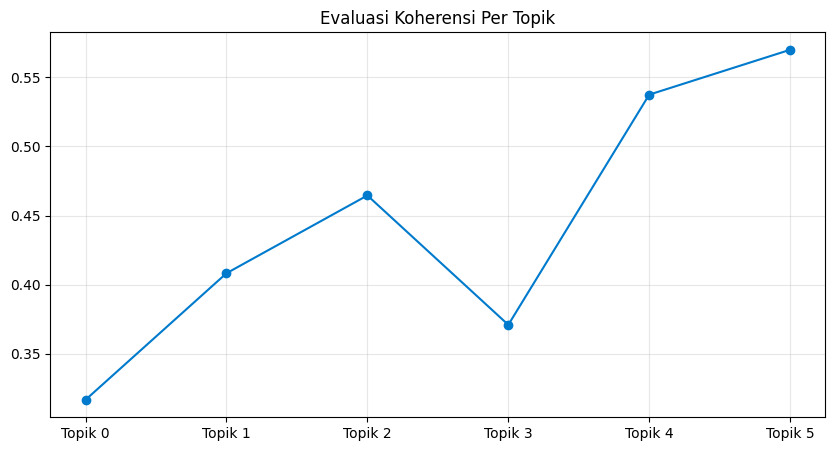

In [17]:
# Penyesuaian Analyzer untuk N-gram
analyzer = vectorizer_model.build_analyzer()
tokens = [analyzer(doc) for doc in documents]
dictionary = Dictionary(tokens)
dictionary.filter_extremes(no_below=3, no_above=0.9)

valid_topics = [t for t in topic_model.get_topics() if t != -1]
topic_words = [[w for w, _ in topic_model.get_topic(t) if w in dictionary.token2id] for t in valid_topics]

if topic_words:
    cm = CoherenceModel(topics=topic_words, texts=tokens, dictionary=dictionary, coherence='c_v')
    print(f"📊 Skor Koherensi Rata-rata (c_v): {cm.get_coherence():.4f}")

    # Plot Grafik
    scores = cm.get_coherence_per_topic()
    plt.figure(figsize=(10, 5))
    plt.plot([f"Topik {t}" for t in valid_topics], scores, marker='o', linestyle='-', color='#007acc')
    plt.title("Evaluasi Koherensi Per Topik")
    plt.grid(True, alpha=0.3)
    plt.show()

# Simpan untuk Streamlit
topic_model.save("my_bertopic_model", serialization="safetensors", save_ctfidf=True)
df_final['Topic'] = topics
df_final.to_csv("data_hasil_topik.csv", index=False)
topic_info.to_csv("info_topik_lengkap.csv", index=False)

#PENYIMPANAN DATA FINAL (LOKAL)

In [18]:
try:
    if 'coherence_per_topic' in globals():
        df_skor = pd.DataFrame({'Topic': valid_topics, 'Coherence_Score': coherence_per_topic})
        # Pastikan tidak ada duplikasi kolom jika cell ini di-run berulang kali
        if 'Coherence_Score' in topic_info.columns:
            topic_info = topic_info.drop(columns=['Coherence_Score'])
        topic_info = topic_info.merge(df_skor, on='Topic', how='left')

    topic_model.save("my_bertopic_model", serialization="safetensors", save_ctfidf=True)
    df_final.to_csv("data_hasil_topik.csv", index=False)
    topic_info.to_csv("info_topik_lengkap.csv", index=False)
    print(f"💾 File CSV dan Model berhasil diperbarui.")
except Exception as e:
    print(f"❌ Error saat menyimpan: {e}")

💾 File CSV dan Model berhasil diperbarui.


#STREAMLIT

In [21]:
!pip install -q streamlit streamlit-option-menu

In [24]:
%%writefile app.py

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from bertopic import BERTopic
import re
from streamlit_option_menu import option_menu

# ==============================================================================
# 1. PAGE CONFIG & SESSION STATE
# ==============================================================================
st.set_page_config(
    page_title="Dashboard MBG | Nanda Pramudya Lestari",
    page_icon="🍽️",
    layout="wide",
    initial_sidebar_state="expanded"
)

if "theme_mode" not in st.session_state:
    st.session_state.theme_mode = "Dark Mode"

def toggle_theme():
    st.session_state.theme_mode = "Light Mode" if st.session_state.theme_mode == "Dark Mode" else "Dark Mode"

# Definisi Palet Warna
if st.session_state.theme_mode == "Dark Mode":
    bg_app, text_color, card_bg, text_main, text_sub, text_accent, wc_bg = "#0E1117", "#FAFAFA", "#1E293B", "#F8FAFC", "#94A3B8", "#FBBF24", "black"
else:
    bg_app, text_color, card_bg, text_main, text_sub, text_accent, wc_bg = "#F4F6F9", "#111827", "#FFFFFF", "#0F172A", "#64748B", "#D97706", "white"

st.markdown(f"""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Plus+Jakarta+Sans:wght@400;600;700&display=swap');
    html, body, .stApp {{ font-family: 'Plus Jakarta Sans', sans-serif; background-color: {bg_app} !important; color: {text_color} !important; }}
    [data-testid="stHeaderActionElements"] {{ display: none !important; }}
    header {{ background-color: transparent !important; }}
    [data-testid="stPlotlyChart"] {{ background-color: {card_bg}; border-radius: 15px !important; padding: 10px; box-shadow: 0 4px 10px rgba(0,0,0,0.05); overflow: hidden; }}
    div[data-testid="stButton"] button {{ background-color: transparent !important; border: none !important; font-size: 28px !important; box-shadow: none !important; padding: 0 !important; }}
</style>
""", unsafe_allow_html=True)

# ==============================================================================
# 2. LOAD DATA
# ==============================================================================
@st.cache_data
def load_data():
    try:
        df = pd.read_csv("data_hasil_topik.csv")
        info = pd.read_csv("info_topik_lengkap.csv")

        if 'topic' in df.columns: df.rename(columns={'topic': 'Topic'}, inplace=True)

        date_col = next((c for c in df.columns if c in ['waktu_tweet', 'created_at', 'date']), None)
        if date_col:
            df['created_at'] = pd.to_datetime(df[date_col], errors='coerce')
        else:
            df['created_at'] = pd.to_datetime('2025-01-01')

        return df, info
    except Exception as e:
        return None, None

@st.cache_resource
def load_model():
    return BERTopic.load("my_bertopic_model") if os.path.exists("my_bertopic_model") else None

df, info_topik = load_data()
topic_model = load_model()

if df is None:
    st.error("❌ Error: File CSV tidak ditemukan. Pastikan file 'data_hasil_topik.csv' dan 'info_topik_lengkap.csv' tersedia.")
    st.stop()

# ==============================================================================
# 3. SIDEBAR & NAVIGATION
# ==============================================================================
with st.sidebar:
    col1, col2 = st.columns([3, 1])
    with col1: st.image("https://cdn-icons-png.flaticon.com/512/2083/2083213.png", width=70)
    with col2: st.button("☀️" if st.session_state.theme_mode == "Dark Mode" else "🌙", on_click=toggle_theme)

    st.markdown("<h3 style='margin-top:-10px;'>MBG Analytics</h3>", unsafe_allow_html=True)

    selected = option_menu(
        menu_title=None,
        options=["Executive Summary", "Topic Explorer", "Analytical Charts", "Raw Data"],
        icons=["speedometer2", "search", "pie-chart", "database"],
        default_index=0,
        styles={
            "container": {"padding": "0!important", "background-color": "transparent"},
            "nav-link": {"font-size": "14px", "text-align": "left", "margin": "5px", "--hover-color": "#334155", "color": text_color},
            "nav-link-selected": {"background-color": "#FFC107", "color": "black", "font-weight": "bold"},
        }
    )

    st.markdown("---")
    st.info(f"**Peneliti:**\n\n**Nanda Pramudya Lestari**\n\nUniversitas Tiga Serangkai")

# ==============================================================================
# 4. MAIN CONTENT
# ==============================================================================

# Perhitungan Metrik Dinamis
if 'Coherence_Score' in info_topik.columns:
    rata_coherence = info_topik[info_topik['Topic'] != -1]['Coherence_Score'].mean()
    coherence_dinamis = f"{rata_coherence:.3f}"
else:
    coherence_dinamis = "N/A"

min_date, max_date = df['created_at'].min(), df['created_at'].max()
tahun_dinamis = min_date.strftime('%Y') if min_date.year == max_date.year else f"{min_date.year}-{max_date.year}"

if selected == "Executive Summary":
    st.title("📊 Executive Summary")

    m1, m2, m3, m4 = st.columns(4)
    metrics = [
        ("TOTAL DATASET", f"{len(df):,}", "Tweet"),
        ("TOPIC CLUSTERS", f"{len(info_topik)-1}", "Kategori"),
        ("COHERENCE SCORE", coherence_dinamis, "Nilai C_v Rata-rata"),
        ("TAHUN ANALISIS", tahun_dinamis, "Periode Data")
    ]

    for col, (t, v, u) in zip([m1, m2, m3, m4], metrics):
        col.markdown(f"""
            <div style="background-color: {card_bg}; border-radius: 15px; padding: 20px; border-top: 5px solid #FFC107; text-align: center;">
                <p style="color: {text_sub}; font-size: 11px; font-weight: 700; margin: 0;">{t}</p>
                <h2 style="color: {text_main}; margin: 10px 0;">{v}</h2>
                <p style="color: {text_accent}; font-size: 13px; font-weight: 600; margin: 0;">{u}</p>
            </div>
        """, unsafe_allow_html=True)

    st.write("---")
    c1, c2 = st.columns(2)

    with c1:
        st.subheader("🏆 Distribusi Volume Topik")
        chart_data = info_topik[info_topik['Topic'] != -1].sort_values('Count', ascending=True).tail(8)
        fig_bar = px.bar(chart_data, x='Count', y='Name', orientation='h', color='Count', color_continuous_scale='Viridis')
        fig_bar.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)', font=dict(color=text_main), height=350)
        st.plotly_chart(fig_bar, use_container_width=True)

    with c2:
        st.subheader("🎯 Nilai Koherensi per Topik")
        if 'Coherence_Score' in info_topik.columns:
            coh_data = info_topik[info_topik['Topic'] != -1].dropna(subset=['Coherence_Score']).sort_values('Coherence_Score')
            fig_coh = go.Figure()
            for i in range(len(coh_data)):
                fig_coh.add_shape(type='line', x0=0, y0=i, x1=coh_data.iloc[i]['Coherence_Score'], y1=i, line=dict(color=text_sub, width=2))
            fig_coh.add_trace(go.Scatter(x=coh_data['Coherence_Score'], y=coh_data['Name'], mode='markers', marker=dict(color='#D97706', size=12)))
            fig_coh.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)', font=dict(color=text_main), height=350, showlegend=False)
            st.plotly_chart(fig_coh, use_container_width=True)

elif selected == "Topic Explorer":
    st.title("🔍 Topic Explorer")
    active_topics = info_topik[info_topik['Topic'] != -1]
    choice = st.selectbox("Pilih Topik:", active_topics['Name'])
    topic_id = active_topics[active_topics['Name'] == choice]['Topic'].values[0]

    t1, t2, t3 = st.tabs(["☁️ Word Cloud", "📄 Dokumen", "📊 Keyword Weights"])

    with t1:
        text_data = " ".join(df[df['Topic'] == topic_id]['step_6_final'].astype(str))
        if len(text_data) > 20:
            wc = WordCloud(width=800, height=400, background_color=wc_bg, colormap='viridis').generate(text_data)
            fig, ax = plt.subplots()
            ax.imshow(wc)
            ax.axis("off")
            fig.patch.set_facecolor(bg_app)
            st.pyplot(fig)
        else:
            st.warning("Data tidak cukup untuk WordCloud.")

    with t2:
        st.dataframe(df[df['Topic'] == topic_id][['created_at', 'full_text']].head(100), use_container_width=True)

    with t3:
        if topic_model:
            fig_weight = topic_model.visualize_barchart(topics=[topic_id], n_words=10)
            st.plotly_chart(fig_weight, use_container_width=True)
        else:
            st.info("Model BERTopic tidak termuat.")

elif selected == "Analytical Charts":
    st.title("📈 Advanced Analytics")

    st.subheader("📅 Tren Percakapan Harian")
    trend = df.resample('D', on='created_at').count()['full_text'].reset_index()
    fig_line = px.line(trend, x='created_at', y='full_text', markers=True, color_discrete_sequence=['#F59E0B'])
    fig_line.update_layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)', font=dict(color=text_main))
    st.plotly_chart(fig_line, use_container_width=True)

    st.subheader("🌳 Treemap Proporsi Topik")
    fig_tree = px.treemap(info_topik[info_topik['Topic'] != -1], path=['Name'], values='Count', color='Count')
    st.plotly_chart(fig_tree, use_container_width=True)

elif selected == "Raw Data":
    st.title("📑 Raw Data")
    query = st.text_input("🔍 Cari Keyword:")
    res = df[df['full_text'].str.contains(query, case=False)] if query else df
    st.dataframe(res[['created_at', 'full_text', 'Topic']].head(500), use_container_width=True)

Overwriting app.py


#RUNNING STREAMLIT

In [ ]:
# Install tambahan untuk desain Streamlit
!pip install -q streamlit streamlit-option-menu
!npm install localtunnel

import urllib
print("\n=====================================================")
print("🌐 Password / Endpoint IP Anda adalah:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())
print("=====================================================")
print("👉 Klik link biru berakhiran 'loca.lt' di bawah ini, lalu masukkan Password/IP di atas.")

!pkill -f streamlit
!pkill -f localtunnel
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
up to date, audited 23 packages in 2s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠙
🌐 Password / Endpoint IP Anda adalah: 34.55.130.174
👉 Klik link biru berakhiran 'loca.lt' di bawah ini, lalu masukkan Password/IP di atas.
⠙⠹your url is: https://purple-donuts-take.loca.lt
